In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, VotingClassifier

from imblearn.over_sampling import SMOTE

from xgboost import XGBClassifier

In [2]:
# 2. LOAD DATASET

df = pd.read_excel("DDos.pcap_ISCX.xlsx")

print("Dataset Shape:", df.shape)
print(df.head())

Dataset Shape: (225745, 79)
    Destination Port   Flow Duration   Total Fwd Packets  \
0              54865               3                   2   
1              55054             109                   1   
2              55055              52                   1   
3              46236              34                   1   
4              54863               3                   2   

    Total Backward Packets  Total Length of Fwd Packets  \
0                        0                           12   
1                        1                            6   
2                        1                            6   
3                        1                            6   
4                        0                           12   

    Total Length of Bwd Packets   Fwd Packet Length Max  \
0                             0                       6   
1                             6                       6   
2                             6                       6   
3                   

In [3]:
# 3. DATA CLEANING & PREPROCESSING

# Remove extra spaces from column names
df.columns = df.columns.str.strip()

# Replace infinite values with NaN
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# Drop missing values
df.dropna(inplace=True)

# Encode target label
le = LabelEncoder()
df['Label'] = le.fit_transform(df['Label'])

print("\nClass Distribution (Before Balancing):")
print(df['Label'].value_counts())


Class Distribution (Before Balancing):
Label
1    128025
0     97686
Name: count, dtype: int64


In [4]:
# 4. SIMPLE FEATURE ENGINEERING

# Avoid division by zero
df['Flow Duration'] = df['Flow Duration'].replace(0, 1)

# Packets per second
df['Packets_per_Second'] = (
    df['Total Fwd Packets'] + df['Total Backward Packets']
) / df['Flow Duration']

# Bytes per second
df['Bytes_per_Second'] = (
    df['Total Length of Fwd Packets'] + df['Total Length of Bwd Packets']
) / df['Flow Duration']

# Forward / Backward packet ratio
df['Fwd_Bwd_Packet_Ratio'] = (
    df['Total Fwd Packets'] / (df['Total Backward Packets'] + 1)
)

In [5]:
# 5. TRAIN-TEST SPLIT

X = df.drop('Label', axis=1)
y = df['Label']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [6]:
# 6. HANDLE CLASS IMBALANCE (SMOTE)

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("\nClass Distribution (After SMOTE - Training Data):")
print(pd.Series(y_train_res).value_counts())



Class Distribution (After SMOTE - Training Data):
Label
1    102420
0    102420
Name: count, dtype: int64


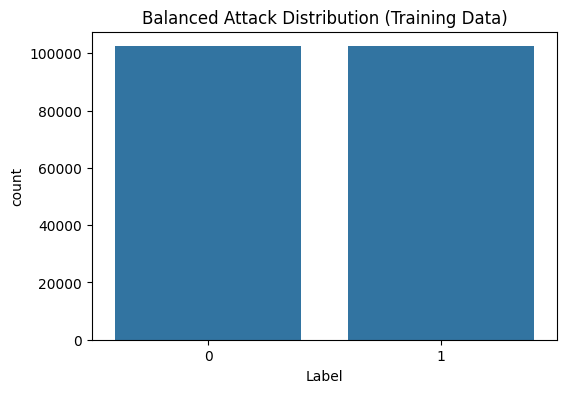

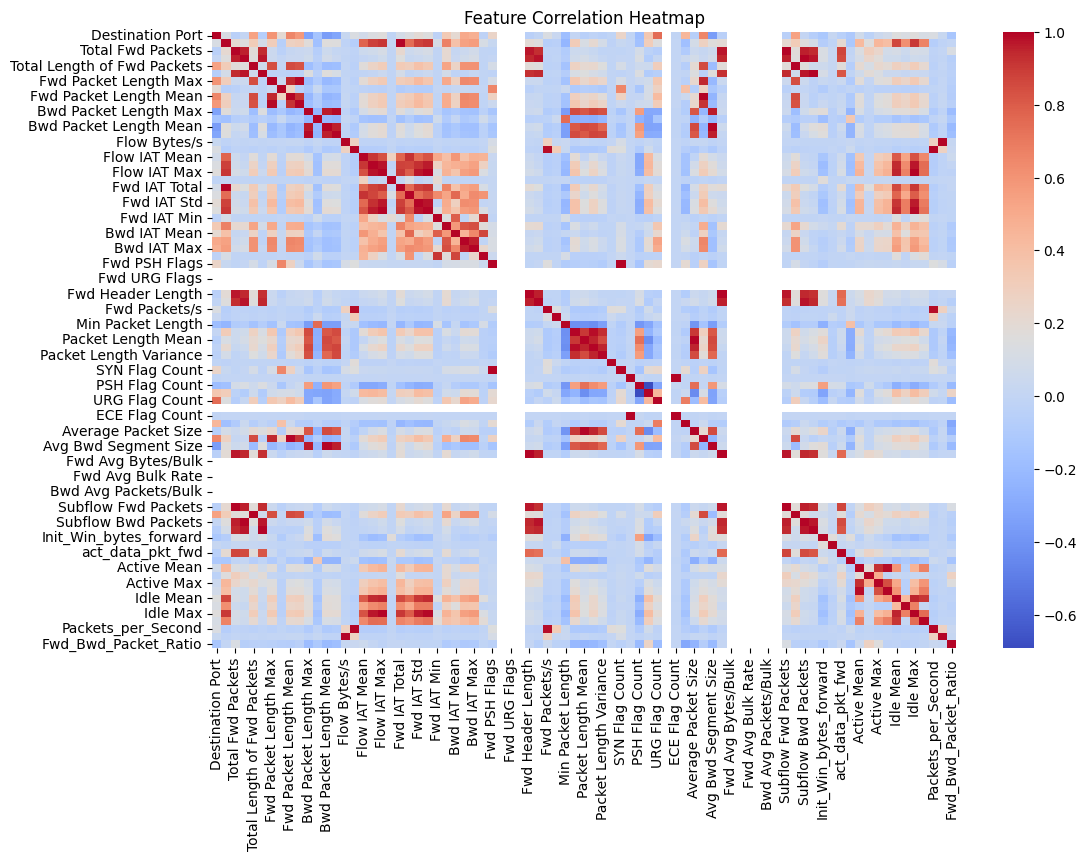

In [7]:
# 7. EXPLORATORY DATA ANALYSIS (EDA)

# Balanced class distribution
plt.figure(figsize=(6,4))
sns.countplot(x=y_train_res)
plt.title("Balanced Attack Distribution (Training Data)")
plt.show()

# Correlation heatmap
plt.figure(figsize=(12,8))
sns.heatmap(X_train_res.corr(), cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

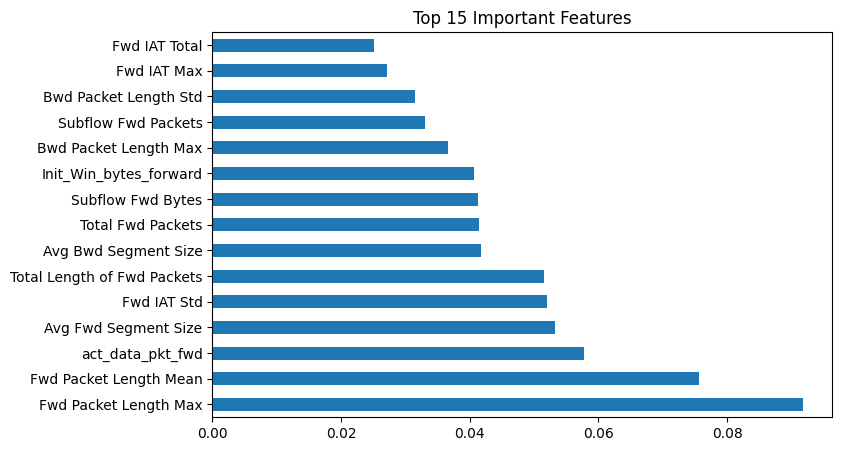

In [8]:
# 8. FEATURE SELECTION (Random Forest)

rf_selector = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_selector.fit(X_train_res, y_train_res)

feature_importance = pd.Series(
    rf_selector.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

top_features = feature_importance.head(15)

# Plot important features
plt.figure(figsize=(8,5))
top_features.plot(kind='barh')
plt.title("Top 15 Important Features")
plt.show()

# Select features
X_train_sel = X_train_res[top_features.index]
X_test_sel = X_test[top_features.index]

In [9]:
# 9. MODEL TRAINING

# Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_sel, y_train_res)

# Random Forest
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)
rf.fit(X_train_sel, y_train_res)

# Extra Trees
et = ExtraTreesClassifier(
    n_estimators=200,
    random_state=42
)
et.fit(X_train_sel, y_train_res)

# XGBoost
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    eval_metric='mlogloss',
    random_state=42
)
xgb.fit(X_train_sel, y_train_res)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

In [10]:
# 10. ENSEMBLE LEARNING

ensemble_model = VotingClassifier(
    estimators=[
        ('rf', rf),
        ('et', et),
        ('xgb', xgb)
    ],
    voting='soft'
)

ensemble_model.fit(X_train_sel, y_train_res)

VotingClassifier(estimators=[('rf',
                              RandomForestClassifier(n_estimators=200,
                                                     random_state=42)),
                             ('et',
                              ExtraTreesClassifier(n_estimators=200,
                                                   random_state=42)),
                             ('xgb',
                              XGBClassifier(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=None, device=None,
                                            early_stopping_rounds=None,
                                            enable_categorical=False...
                                            feature_weights=None, gamma=None,
                                            grow_policy=None,
                                            importance_type=None,
                                            interaction_constraints=None,
                                            learning_rate=0.1, max_bin=None,
                                            max_cat_threshold=None,
                                            max_cat_to_onehot=None,
                                            max_delta_step=None, max_depth=6,
                                            max_leaves=None,
                                            min_child_weight=None, missing=nan,
                                            monotone_constraints=None,
                                            multi_strategy=None,
                                            n_estimators=200, n_jobs=None,
                                            num_parallel_tree=None, ...))],
                 voting='soft')


Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     19538
           1       1.00      1.00      1.00     25605

    accuracy                           1.00     45143
   macro avg       1.00      1.00      1.00     45143
weighted avg       1.00      1.00      1.00     45143



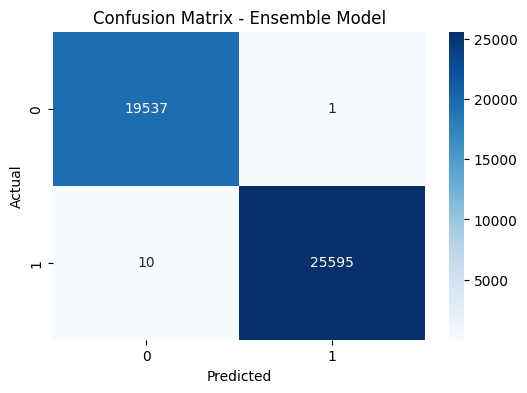

In [11]:
# 11. MODEL EVALUATION

y_pred = ensemble_model.predict(X_test_sel)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(
    confusion_matrix(y_test, y_pred),
    annot=True,
    fmt='d',
    cmap='Blues'
)
plt.title("Confusion Matrix - Ensemble Model")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()